# Getting started with ReLife

## A few words about survival analysis

**Lifetime data** is a specific kind of data that falls under the scope of survival analysis for many use cases. This section will help you understand in which scenarios your data can be treated by the approach implemented in the ReLife package.

You should apply survival analysis to estimate **population-level lifetime behavior of power-system network assets** when lifetimes are uncertain and failures are partially observed. Survival analysis provides estimates of survival probabilities, expected lifetimes and dispersion, age-dependent failure propensity, and uncertainty bounds. These estimates **support decisions** such as replacement timing, maintenance prioritization, technology comparison, and long-term investment planning. A ﬁrst step begins by formulating the operational questions that your analysis must answer. Typical questions are:

- What is the expected remaining lifetime of the asset population ?
- How many failures are expected per year under current operating conditions ?
- How does failure propensity evolve with age ?
- Is the population dominated by early failures or by aging effects ?
- Does one technology or supplier perform better than another ?
- What are the economic implications of delaying or accelerating replacement ?

For more information about **survival analysis concepts**, please read the [Lifelines documentation](https://lifelines.readthedocs.io/en/latest/Survival%20Analysis%20intro.html).

## Why does ReLife use NumPy ?

ReLife is built using [NumPy](https://numpy.org/), a fundamental Python library for numerical computing.
While you don't need to be a NumPy expert, understanding its basics will help since ReLife often requires data input of `np.ndarray` type.

There are 3 standard representations of data in ReLife:

- If you want to pass a scalar value, use `float` built-in type (`np.float64` is accepted but not required).
- If you want to pass a vector of $\mathbb{R}^n$, e.g. $n$ values for one asset, use a `np.ndarray` of shape `(n,)`.
- If you want to pass a matrix of $\mathbb{R}^{m\times n}$, i.e. $n$ values for $m$ assets, use a `np.ndarray` of shape `(m, n)`.

**Broadcasting examples**

In this example, the output has the same number of dimensions as the input.

In [11]:
from relife.lifetime_model import Weibull

weibull = Weibull(3.47, 0.012)
weibull.sf(40.)

np.float64(0.9246627462729304)

To compute $P(T > 40)$, but also $P(T > 50)$ and $P(T > 60)$, we can benefit from [broadcasting](https://numpy.org/doc/stable/user/basics.broadcasting.html) and compute three survival function evaluations in parallel.

In [12]:
import numpy as np

weibull.sf(np.array([40., 50., 60.]))  # 1d array of shape (3,)

array([0.92466275, 0.84375201, 0.72625935])

This logic is extended **until two dimensions**. For instance, it is sometimes useful to pass several values per asset.

In [13]:
weibull.sf(np.array([[40., 50., 60.], [42., 55., 68.]]))  # 2d array of shape (2, 3)

array([[0.92466275, 0.84375201, 0.72625935],
       [0.91139796, 0.78939177, 0.61029328]])

Each row encodes a vector of values for each asset.

## ReLife data format

In the ReLife package, a structure with **three variables (time, event, entry)** is necessary for all analyses :

- `time` : the **time-to-event** or the time until the **end of observation** of an asset.
- `event` : a boolean value indicating **if an event occured or not** during the observation period for the asset. If no event occured, the observations is called **censored** because we don't know if an event will occur or not later during the lifetime of the asset.
- `entry` : the time until an asset was **first observed.** Can be usually determined from maintenance and installation dates.

Note that each asset in a given dataset should appear only once and be described by *at least* these three variables. Covariates can be added for regression tasks.

## Built-in datasets

The ReLife package contains a list of **three built-in datasets** that you can use to start playing with ReLife functions. Here is a quick summary of the content of each dataset, available in the `relife.data` module : 
- `load_circuit_breaker` : a dataset of three variables (time, event, entry) for **circuit breaker assets.**
- `load_power_transformer` : a dataset of three variables (time, event, entry) for **power transformer assets.**
- `load_insulator_string` : a dataset of lifetime variables (time, event, entry) for **insulator strings assets with covariates** (pHCl, pH2SO4, HNO3) for regression tasks.

Loading a built-in dataset with ReLife is straightforward : you just need to import the function and execute it to get a numpy **structarray**. From this structarray, you can either choose to **stay with numpy** or create a **pandas DataFrame** for data manipulation depending on your preferences. 

Let's build a reading and plotting function to have a first look at the data : 

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

from relife.data import (
    load_circuit_breaker,
    load_insulator_string,
    load_power_transformer,
)


def load_dataset_from_name(dataset_name: str) -> pd.DataFrame:
    """
    Load a built-in dataset from name as a pandas DataFrame and print basic information.

    Parameters
    ----------
    dataset_name : str
        Chosen dataset name.

    Returns
    -------
    pd.DataFrame
        Loaded dataset as pandas DataFrame.
    """

    if dataset_name == "circuit_breaker":
        loaded_data = load_circuit_breaker()
    elif dataset_name == "power_transformer":
        loaded_data = load_power_transformer()
    elif dataset_name == "insulator_string":
        loaded_data = load_insulator_string()
    else:
        raise ValueError(
            f"Unknown dataset '{dataset_name}'. Expected one of: " + 
            "'circuit_breaker', 'power_transformer', 'insulator_string'."
        )
    
    print("Dataset type : ", type(loaded_data))
    print("Dataset shape : ", len(loaded_data), ",", len(loaded_data[0]))

    df = pd.DataFrame(loaded_data)
    
    return df

def plot_dataset_distributions(df: pd.DataFrame) -> None:
    """Generates a (time, event, entry) distribution plot for a given dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset with at least (time, event, entry) columns.
    """
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    df['time'].plot(
        kind='hist', ax=axes[0], title='time', color='#3a86ff', edgecolor='none'
    )
    df['event'].value_counts().plot(
        kind='bar', ax=axes[1], title='event', color=['#ff6b6b', '#4ecdc4'], 
        edgecolor='none', rot=0
    )
    df['entry'].plot(
        kind='hist', ax=axes[2], title='entry', color='#8338ec', edgecolor='none'
    )
    plt.tight_layout()
    plt.show()

The first dataset is related to **circuit breakers**. It contains only the mandatory fields (time, event, entry) that are needed for most ReLife functions.

In [15]:
circuit_breaker_df = load_dataset_from_name("circuit_breaker")
circuit_breaker_df.head()

Dataset type :  <class 'numpy.ndarray'>
Dataset shape :  4204 , 3


,time,event,entry
0,34.0,True,33.0
1,28.0,True,27.0
2,12.0,True,11.0
3,38.0,True,37.0
4,18.0,True,17.0


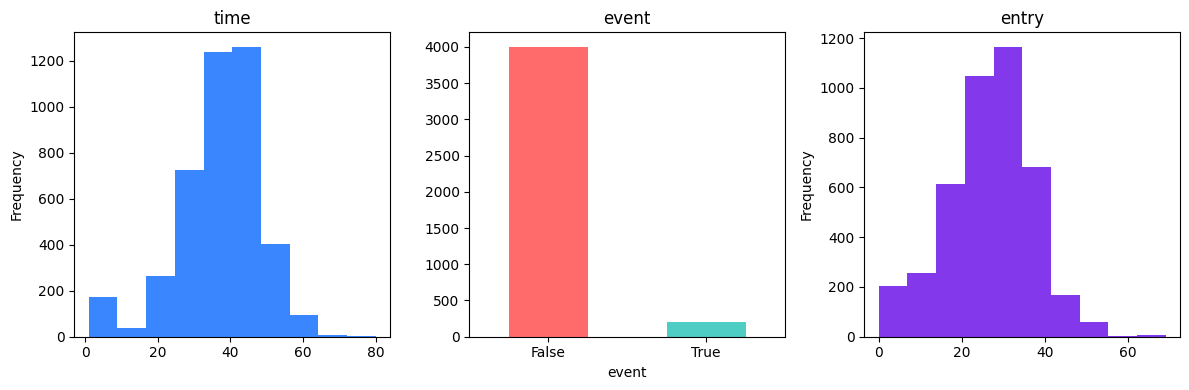

In [16]:
plot_dataset_distributions(circuit_breaker_df)

Another available dataset is related to **power transformers** and has the same structure as the **circuit breaker** dataset :

In [17]:
transformers_df = load_dataset_from_name("power_transformer")
transformers_df.head()

Dataset type :  <class 'numpy.ndarray'>
Dataset shape :  1650 , 3


,time,event,entry
0,34.3,True,34.0
1,45.1,True,44.0
2,53.2,True,52.0
3,48.2,True,47.0
4,33.2,True,32.0


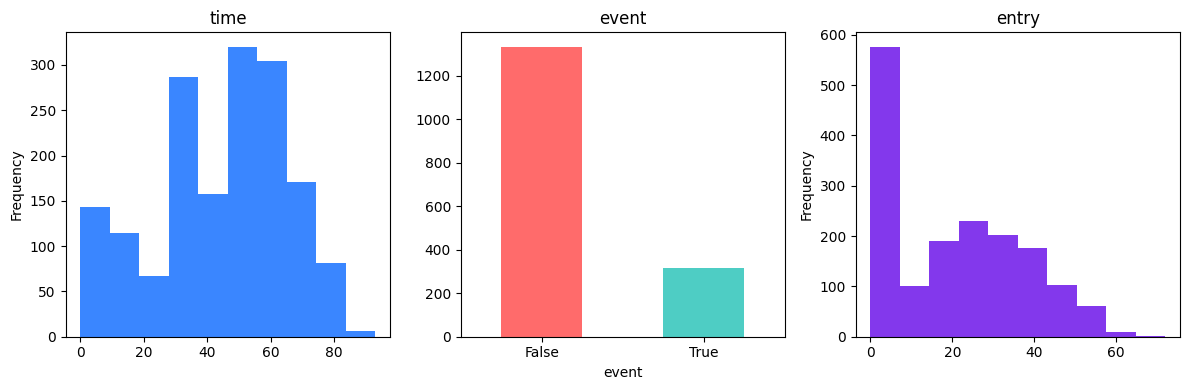

In [18]:
plot_dataset_distributions(transformers_df)

Simply note that the distribution of the input data is different depending on the asset. Remember to always create your input datasets *at least* by asset type to avoid mixing data that are unrelated. Please read the **recommendations section** below for more information about dataset creation.

The last available dataset is related to **insulator strings** and contains the three mandatory variables (time, event, entry) and three covariates that you can use for regression tasks :

In [19]:
insulators_df = load_dataset_from_name("insulator_string")
insulators_df.head()

Dataset type :  <class 'numpy.ndarray'>
Dataset shape :  12000 , 6


,time,event,entry,pHCl,pH2SO4,HNO3
0,70.0,False,40.0,0.49,1.69,0.24
1,30.0,False,0.0,0.76,1.79,0.39
2,45.0,False,15.0,0.43,1.61,0.25
3,78.0,False,48.0,0.50,1.80,0.28
4,106.0,False,76.0,0.34,1.55,0.26


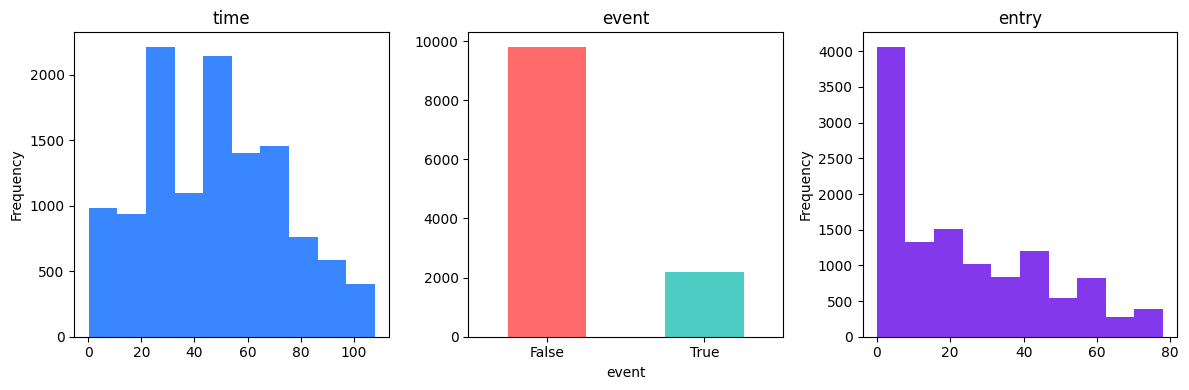

In [20]:
plot_dataset_distributions(insulators_df)

Adding **covariates** to our dataset is interesting if we suspect that **external factors can influence the event.** Regression techniques implemented in ReLife can be used to assess the effect of each variable on the lifetime of an asset. Have a look at the [Lifetime regression](https://opensource.rte-france.com/relife/user/lifetime_regressions.html) section for more information !

## Recommendations for event definition and dataset creation

These dataset are a good starting point to understand the ReLife data structure and to start playing with the package easily. But ReLife was made to use **real-life datasets** and to get the best out of your data to make **informed decisions** for your asset management. Most of the time, real life data can be messy. This section helps you creating a **ReLife-compatible dataset** from your data and identify **common bias** in dataset creation.

### Event definition

Power system assets experience many event types: scheduled replacements, age-based maintenance, corrective repairs, partial refurbishments. **Mixing event types leads to biased lifetime estimates**. For now, we cover **non-repairable assets items and failure modes that occur at most once per asset**, for populations of assets assumed to be technically homogeneous and datasets containing both failed and in service assets. It addresses situations in which:
- Only a fraction of the assets failed
- Assets are observed over a limited time period
- Some assets enter the observation period after installation
- Preventive replacements occur

For instance, considerer choosing an event like *"My asset experienced a failure"*. When collecting your data, you will label with zeros the absence of known failure of your assets and with ones the observation of an event within the time frame you defined.

### Data collection

- Collect **installation dates** for your assets
    * The most common data to collect in your systems in order to create a ReLife-compatible dataset is the installation date of your assets. It is mandatory to create the `time` and `entry` fields that are necessary for ReLife functions. If we consider $D_{install}$ the installation date, $D_{start}$ the date of first observation of an asset, $D_{end}$ the date of last observation and $D_{event}$ the date of an event :  
        * $entry=D_{start}-D_{install}$ if the asset has been always observed
        * $time=D_{end}-D_{install}$ if no event registered
        * $time=D_{event}-D_{install}$ if an event occured during the observation period (failure or preventive replacement)
    * Common mistakes would be to use unreliable data or fill the missing values for this date, thus propagating errors into the subsequent models.
    * One recommandation would be to **ignore the data points where you don't have any installation dates**, while keeping in mind that the quality of the models will depend greatly on the quality of your input data.
- Collect the **event data**
    * If your data is easily accessible, collect your event dates for all your assets. Be careful when creating the event flag for ReLife usage, since the **absence of event might not always be a "non-event"** depending on the way you collect your data. Only fill the event flag with zeros if you are certain that no event occured.
    * Remember to also **get your preventive replacement events** to calculate correctly the `time` field in your dataset.
    * Event dates and information may be in maintenance notes, PDF work orders or technician remarks, not in structured columns. Considerer using appropriate methods for data extraction if your data is in free-text fields (regular expressions, character recognition or even LLM calls). If so, keep in mind that **the process of data extraction might introduce errors** that would propagate to the subsequent models. A proper **data quality check** might be necessary.
    * Event dates can be approximate. For instance, **if a maintenance check "discovered" an asset failure**, your real date of event is inside a time interval of the form **[penultimate_check, last_check_date]**. ReLife can model this correctly, but only if the data is structured as [left_bound, right_bound] rather than forcing a single date.
- Optionnally collect **covariates**
    * When available, consider collecting covariates to better fit your lifetime distributions.
    * Covariates may be standardized for better interpretation of results
    * Remember that not all methods implemented in the ReLife package can be used with covariates. Consider using appropriate methods if your dataset have some.